In [ ]:


import numpy as np 
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/architsharma01/loan-approval-prediction-dataset/loan_approval_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/architsharma01/loan-approval-prediction-dataset/loan_approval_dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

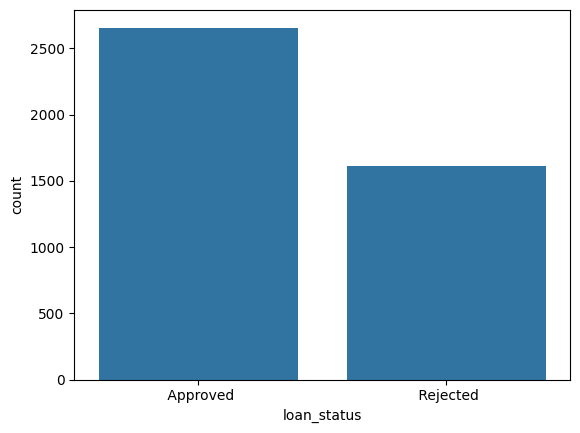

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(
    data=df,
    x="loan_status"
)

plt.show()

# Feature engineering

In [8]:
df["total_assets"] = (
    df["residential_assets_value"]
    + df["commercial_assets_value"]
    + df["luxury_assets_value"]
    + df["bank_asset_value"]
)

In [9]:
df["loan_income_ratio"] = (
    df["loan_amount"]
    /
    (df["income_annum"] + 1)
)

In [10]:
df["monthly_income"] = (
    df["income_annum"] / 12
)


df["loan_term_months"] = (
    df["loan_term"] * 12
)


df["emi_ratio"] = (
    df["loan_amount"]
    /
    (df["loan_term_months"] + 1)
) / (df["monthly_income"] + 1)

In [11]:
df["asset_loan_ratio"] = (
    df["total_assets"]
    /
    (df["loan_amount"] + 1)
)

In [12]:
df["income_per_dependent"] = (
    df["income_annum"]
    /
    (df["no_of_dependents"] + 1)
)

In [13]:
def cibil_category(x):
    if x < 600:
        return "Poor"
    elif x < 750:
        return "Average"
    else:
        return "Good"


df["cibil_category"] = df["cibil_score"].apply(
    cibil_category
)

In [14]:
df = pd.get_dummies(
    df,
    columns=["cibil_category"],
    drop_first=True
)

In [15]:
df["financial_strength"] = (
    df["income_annum"]
    +
    df["total_assets"]
)

In [16]:
df["bank_asset_ratio"] = (
    df["bank_asset_value"]
    /
    (df["total_assets"] + 1)
)


df["property_asset_ratio"] = (
    df["residential_assets_value"]
    /
    (df["total_assets"] + 1)
)

In [17]:
import numpy as np


log_cols = [
    "income_annum",
    "loan_amount",
    "total_assets",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]


for col in log_cols:
    df[col+"_log"] = np.log1p(
        df[col]
    )

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   loan_id                       4269 non-null   int64  
 1   no_of_dependents              4269 non-null   int64  
 2   education                     4269 non-null   object 
 3   self_employed                 4269 non-null   object 
 4   income_annum                  4269 non-null   int64  
 5   loan_amount                   4269 non-null   int64  
 6   loan_term                     4269 non-null   int64  
 7   cibil_score                   4269 non-null   int64  
 8   residential_assets_value      4269 non-null   int64  
 9   commercial_assets_value       4269 non-null   int64  
 10  luxury_assets_value           4269 non-null   int64  
 11  bank_asset_value              4269 non-null   int64  
 12  loan_status                   4269 non-null   object 
 13  tot

In [19]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,...,financial_strength,bank_asset_ratio,property_asset_ratio,income_annum_log,loan_amount_log,total_assets_log,residential_assets_value_log,commercial_assets_value_log,luxury_assets_value_log,bank_asset_value_log
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,...,60300000,0.157791,0.047337,16.077274,17.213369,17.741436,14.690980,16.683410,16.937876,15.894952
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,...,21100000,0.194118,0.158824,15.226498,16.316947,16.648724,14.808763,14.603968,15.990262,15.009433
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,...,66800000,0.221837,0.123050,16.023785,17.206658,17.870768,15.775605,15.319588,17.321068,16.364956
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,...,60900000,0.149905,0.345351,15.919645,17.239773,17.780126,16.716932,15.009433,16.963964,15.882373
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,...,64800000,0.090909,0.225455,16.097893,17.001863,17.822844,16.333207,15.919645,17.196505,15.424949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,...,8400000,0.108108,0.378378,13.815512,14.648420,15.816991,14.845130,13.122365,15.009433,13.592368
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,...,23300000,0.095000,0.210000,15.009433,16.240313,16.811243,15.250595,14.880222,16.213406,14.457365
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,...,45500000,0.187179,0.030769,15.687313,16.989389,17.479072,13.997833,16.333207,16.711423,15.803385
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,...,32900000,0.201389,0.284722,15.226498,16.364956,17.175886,15.919645,13.458837,16.461685,15.573369


# Encodding

In [20]:
cat_cols = [
    "education",
    "self_employed",
    "loan_status"
]


for col in cat_cols:
    print(col)
    print(df[col].value_counts())
    print("----------------")

education
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64
----------------
self_employed
self_employed
Yes    2150
No     2119
Name: count, dtype: int64
----------------
loan_status
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
----------------


In [21]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

df["loan_status"] = le.fit_transform(
    df["loan_status"]
)


print(df["loan_status"].value_counts())

loan_status
0    2656
1    1613
Name: count, dtype: int64


In [22]:
print(
    dict(
        zip(
            le.classes_,
            le.transform(le.classes_)
        )
    )
)

{' Approved': np.int64(0), ' Rejected': np.int64(1)}


In [23]:
from sklearn.preprocessing import LabelEncoder


for col in [
    "education",
    "self_employed"
]:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(
        df[col]
    )

In [24]:
bool_cols = df.select_dtypes(
    include="bool"
).columns


df[bool_cols] = df[bool_cols].astype(int)

In [25]:
df.isna().sum()

loan_id                          0
no_of_dependents                 0
education                        0
self_employed                    0
income_annum                     0
loan_amount                      0
loan_term                        0
cibil_score                      0
residential_assets_value         0
commercial_assets_value          0
luxury_assets_value              0
bank_asset_value                 0
loan_status                      0
total_assets                     0
loan_income_ratio                0
monthly_income                   0
loan_term_months                 0
emi_ratio                        0
asset_loan_ratio                 0
income_per_dependent             0
cibil_category_Good              0
cibil_category_Poor              0
financial_strength               0
bank_asset_ratio                 0
property_asset_ratio             0
income_annum_log                 0
loan_amount_log                  0
total_assets_log                 0
residential_assets_v

**Null Value**

In [26]:
df.fillna(
    df.median(numeric_only=True),
    inplace=True
)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   loan_id                       4269 non-null   int64  
 1   no_of_dependents              4269 non-null   int64  
 2   education                     4269 non-null   int64  
 3   self_employed                 4269 non-null   int64  
 4   income_annum                  4269 non-null   int64  
 5   loan_amount                   4269 non-null   int64  
 6   loan_term                     4269 non-null   int64  
 7   cibil_score                   4269 non-null   int64  
 8   residential_assets_value      4269 non-null   int64  
 9   commercial_assets_value       4269 non-null   int64  
 10  luxury_assets_value           4269 non-null   int64  
 11  bank_asset_value              4269 non-null   int64  
 12  loan_status                   4269 non-null   int64  
 13  tot

# Prepare X and y

In [28]:
X = df.drop(columns=['loan_id','loan_status'])
y = df["loan_status"]

In [29]:
X

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,...,financial_strength,bank_asset_ratio,property_asset_ratio,income_annum_log,loan_amount_log,total_assets_log,residential_assets_value_log,commercial_assets_value_log,luxury_assets_value_log,bank_asset_value_log
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,...,60300000,0.157791,0.047337,16.077274,17.213369,17.741436,14.690980,16.683410,16.937876,15.894952
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,...,21100000,0.194118,0.158824,15.226498,16.316947,16.648724,14.808763,14.603968,15.990262,15.009433
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,...,66800000,0.221837,0.123050,16.023785,17.206658,17.870768,15.775605,15.319588,17.321068,16.364956
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,...,60900000,0.149905,0.345351,15.919645,17.239773,17.780126,16.716932,15.009433,16.963964,15.882373
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,...,64800000,0.090909,0.225455,16.097893,17.001863,17.822844,16.333207,15.919645,17.196505,15.424949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,...,8400000,0.108108,0.378378,13.815512,14.648420,15.816991,14.845130,13.122365,15.009433,13.592368
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,...,23300000,0.095000,0.210000,15.009433,16.240313,16.811243,15.250595,14.880222,16.213406,14.457365
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,...,45500000,0.187179,0.030769,15.687313,16.989389,17.479072,13.997833,16.333207,16.711423,15.803385
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,...,32900000,0.201389,0.284722,15.226498,16.364956,17.175886,15.919645,13.458837,16.461685,15.573369


In [30]:
from sklearn.model_selection import train_test_split


X = df.drop(
    "loan_status",
    axis=1
)

y = df["loan_status"]


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
X_train

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,...,financial_strength,bank_asset_ratio,property_asset_ratio,income_annum_log,loan_amount_log,total_assets_log,residential_assets_value_log,commercial_assets_value_log,luxury_assets_value_log,bank_asset_value_log
1224,1225,0,0,1,9800000,23900000,14,459,1000000,13400000,...,52500000,0.168618,0.023419,16.097893,16.989389,17.569710,13.815512,16.410765,16.864784,15.789592
478,479,3,1,1,3600000,8600000,8,790,5400000,5900000,...,29900000,0.197719,0.205323,15.096445,15.967273,17.085080,15.501910,15.590463,16.097893,15.464169
3065,3066,2,1,0,2000000,4000000,14,502,4900000,1500000,...,15100000,0.099237,0.374046,14.508658,15.201805,16.388123,15.404746,14.220976,15.501910,14.077876
326,327,2,1,1,3900000,11300000,12,516,3100000,0,...,22000000,0.254144,0.171271,15.176487,16.240313,16.711423,14.946913,0.000000,16.157316,15.341567
2991,2992,3,1,0,2300000,8500000,12,557,3600000,1400000,...,14800000,0.104000,0.288000,14.648420,15.955577,16.341239,15.096445,14.151984,15.640060,14.077876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,24,0,1,1,500000,1400000,2,551,900000,600000,...,3400000,0.103448,0.310345,13.122365,14.151984,14.880222,13.710151,13.304687,13.910822,12.611541
233,234,3,1,1,8800000,34600000,8,386,14800000,16500000,...,64500000,0.107720,0.265709,15.990262,17.359364,17.835491,16.510138,16.618871,16.727861,15.607270
3298,3299,2,1,1,6800000,15500000,12,338,9900000,1200000,...,48200000,0.205314,0.239130,15.732433,16.556351,17.538791,16.108045,13.997833,16.897421,15.955577
1397,1398,1,1,1,9200000,24500000,4,545,25700000,0,...,68800000,0.223154,0.431208,16.034714,17.014184,17.903166,17.062002,0.000000,16.840802,16.403275


# Model

In [32]:
from xgboost import XGBClassifier


model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)


model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [33]:
y_pred = model.predict(
    X_val
)


y_prob = model.predict_proba(
    X_val
)[:,1]

# EVALUTION

In [34]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


accuracy = accuracy_score(
    y_val,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred
)

recall = recall_score(
    y_val,
    y_pred
)

f1 = f1_score(
    y_val,
    y_pred
)

roc_auc = roc_auc_score(
    y_val,
    y_prob
)


print(f"Accuracy           : {accuracy:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")

Accuracy           : 0.9988
Balanced Accuracy  : 0.9991
Precision          : 0.9969
Recall             : 1.0000
F1 Score           : 0.9985
ROC-AUC            : 1.0000


**Classification Report**

In [35]:
from sklearn.metrics import classification_report


print(
    classification_report(
        y_val,
        y_pred,
        target_names=[
            "Approved",
            "Rejected"
        ]
    )
)

              precision    recall  f1-score   support

    Approved       1.00      1.00      1.00       531
    Rejected       1.00      1.00      1.00       323

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



**Confusion Matrix Visualization**

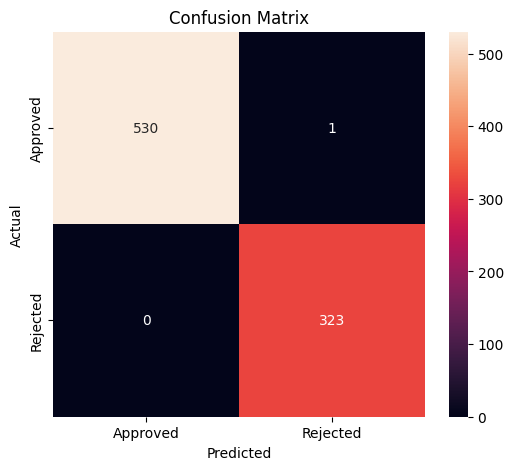

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_val,
    y_pred
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Approved",
        "Rejected"
    ],
    yticklabels=[
        "Approved",
        "Rejected"
    ]
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**ROC Curve**

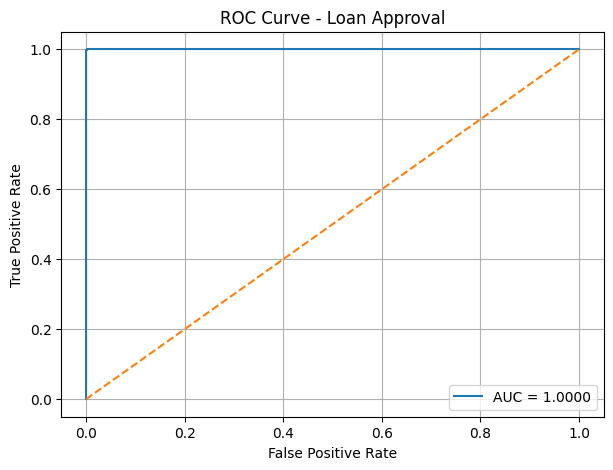

In [37]:
from sklearn.metrics import roc_curve, auc


fpr, tpr, thresholds = roc_curve(
    y_val,
    y_prob
)


roc_auc_value = auc(
    fpr,
    tpr
)


plt.figure(figsize=(7,5))


plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_value:.4f}"
)


plt.plot(
    [0,1],
    [0,1],
    "--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Loan Approval"
)


plt.legend()

plt.grid()

plt.show()

**Precision-Recall Curve**

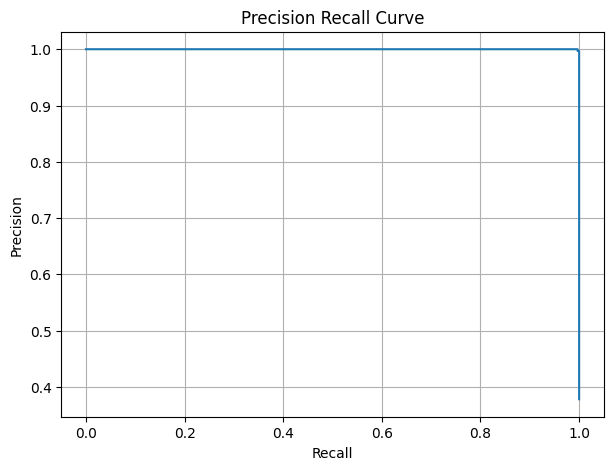

In [38]:
from sklearn.metrics import precision_recall_curve


precision_values, recall_values, _ = precision_recall_curve(
    y_val,
    y_prob
)


plt.figure(figsize=(7,5))


plt.plot(
    recall_values,
    precision_values
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision Recall Curve"
)


plt.grid()

plt.show()

**Prediction Probability Distribution**

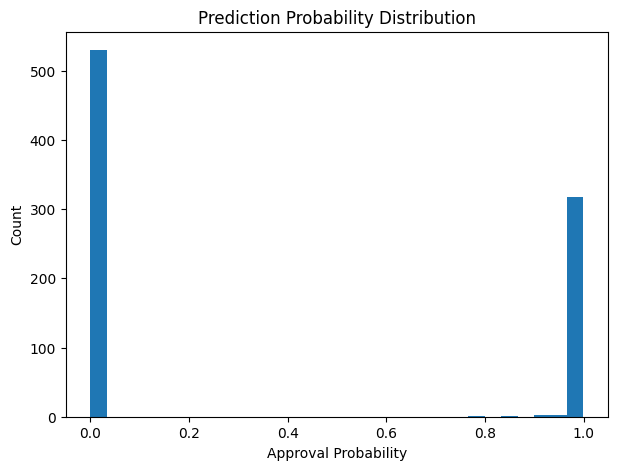

In [39]:
plt.figure(figsize=(7,5))


plt.hist(
    y_prob,
    bins=30
)


plt.xlabel(
    "Approval Probability"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Prediction Probability Distribution"
)


plt.show()

**Metrics Comparison Graph**

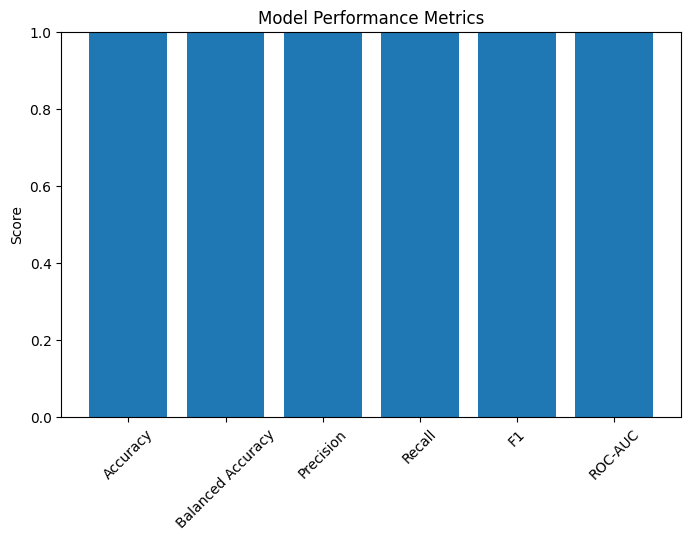

In [40]:
import pandas as pd


metrics_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Score":[
        accuracy,
        balanced_acc,
        precision,
        recall,
        f1,
        roc_auc
    ]

})


plt.figure(figsize=(8,5))


plt.bar(
    metrics_df["Metric"],
    metrics_df["Score"]
)


plt.ylim(
    0,
    1
)


plt.xticks(
    rotation=45
)


plt.title(
    "Model Performance Metrics"
)


plt.ylabel(
    "Score"
)


plt.show()

# Feature Importance (XGBoost)

In [41]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


importance = importance.sort_values(
    "Importance",
    ascending=False
)


importance.head(15)

,Feature,Importance
20,cibil_category_Poor,0.458204
7,cibil_score,0.263003
19,cibil_category_Good,0.108746
15,loan_term_months,0.034350
16,emi_ratio,0.033174
13,loan_income_ratio,0.025859
6,loan_term,0.020433
17,asset_loan_ratio,0.010592
24,income_annum_log,0.008745
23,property_asset_ratio,0.003985


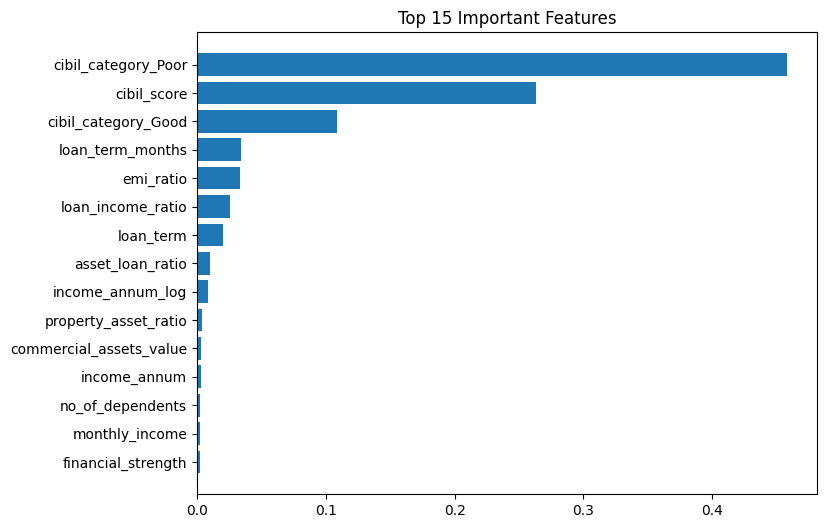

In [42]:
plt.figure(figsize=(8,6))


plt.barh(
    importance["Feature"].head(15),
    importance["Importance"].head(15)
)


plt.gca().invert_yaxis()


plt.title(
    "Top 15 Important Features"
)


plt.show()